# Notebook 06 — Robustness, Drift & Stress Testing
**DNSC 6330 Capstone | HMDA LAR 2024**

Based on Lecture 04: Robustness, Generalization, and Dataset Drift (Akinwumi, April 2026)

**Structure:**
- Part A: Distribution Drift (PSI, KS, MMD)
- Part B: Generalization Gap & Spurious Correlations
- Part C: Robustness & Stress Testing (Slices, Scenarios, ICE)

> **Key principle (Lecture 04):** A model that performs well on a test set is not necessarily robust. Responsible deployment requires evidence of stability under shift, stress, and subgroup variation.

## 0. Setup & Imports

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

import os

# ── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR    = os.getcwd()
FIGURES_DIR = os.path.join(BASE_DIR, 'figures')
TABLES_DIR  = os.path.join(BASE_DIR, 'tables')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR,  exist_ok=True)

from scipy.stats import ks_2samp
from sklearn.metrics import (
    roc_auc_score, accuracy_score, log_loss,
    f1_score, brier_score_loss
)
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 4)

print('Imports OK')
print(f'BASE_DIR:    {BASE_DIR}')
print(f'FIGURES_DIR: {FIGURES_DIR}')
print(f'TABLES_DIR:  {TABLES_DIR}')

Imports OK
BASE_DIR:    /Users/tsotnedzeria-personal/Desktop/RML/capstone
FIGURES_DIR: /Users/tsotnedzeria-personal/Desktop/RML/capstone/figures
TABLES_DIR:  /Users/tsotnedzeria-personal/Desktop/RML/capstone/tables


## 0.1 Load Artifacts

In [9]:
# ── Load train/test splits ───────────────────────────────────────────────────
X_train    = pd.read_parquet(os.path.join(BASE_DIR, 'X_train_imputed.parquet'))
X_test     = pd.read_parquet(os.path.join(BASE_DIR, 'X_test_imputed.parquet'))
y_train    = pd.read_parquet(os.path.join(BASE_DIR, 'y_train.parquet')).squeeze()
y_test     = pd.read_parquet(os.path.join(BASE_DIR, 'y_test.parquet')).squeeze()
prot_train = pd.read_parquet(os.path.join(BASE_DIR, 'prot_train.parquet'))
prot_test  = pd.read_parquet(os.path.join(BASE_DIR, 'prot_test.parquet'))

# ── Load trained model ───────────────────────────────────────────────────────
model = joblib.load(os.path.join(BASE_DIR, 'best_model.pkl'))

with open(os.path.join(BASE_DIR, 'model_meta.json')) as f:
    meta = json.load(f)

with open(os.path.join(BASE_DIR, 'threshold_meta.json')) as f:
    threshold_meta = json.load(f)
THRESHOLD = threshold_meta['global_threshold']

# ── Feature alignment ────────────────────────────────────────────────────────
expected_cols = meta.get('feature_columns', [])
if expected_cols:
    missing = set(expected_cols) - set(X_test.columns)
    extra   = set(X_test.columns) - set(expected_cols)
    if missing: print(f'⚠ Missing cols: {missing}')
    if extra:   print(f'⚠ Extra cols:   {extra}')
    X_train = X_train[expected_cols]
    X_test  = X_test[expected_cols]
    print(f'Feature alignment OK — {len(expected_cols)} columns')

# ── Already imputed — just copy ───────────────────────────────────────────────
X_train_filled = X_train.copy()
X_test_filled  = X_test.copy()

# ── Cap to 500k for tractable permutation importance / ICE ───────────────────
from sklearn.utils import resample
MAX_ROWS = 500_000
if len(X_train_filled) > MAX_ROWS:
    X_train_filled, y_train = resample(
        X_train_filled, y_train,
        n_samples=MAX_ROWS, stratify=y_train, random_state=42
    )
    print(f'Train capped at {MAX_ROWS:,} rows for this notebook')

print(f'X_train: {X_train_filled.shape} | X_test: {X_test_filled.shape}')
print(f'Train approval rate: {y_train.mean():.2%}')
print(f'Test approval rate:  {y_test.mean():.2%}')

Feature alignment OK — 23 columns
Train capped at 500,000 rows for this notebook
X_train: (500000, 23) | X_test: (1732350, 23)
Train approval rate: 75.72%
Test approval rate:  75.72%


---
## Part A: Distribution Drift

> **Lecture 04 question:** *Has the data generating process changed?*
>
> - **PSI** — binned distribution comparison (eq. 4.1)
> - **KS test** — nonparametric two-sample test on CDFs (eq. 4.2)
> - **MMD** — kernel-based test for high-dimensional feature space (eq. 4.3)
>
> PSI/KS are **leading indicators**. Rolling AUC is a **lagging indicator** (Lecture 04, slide 24).

### A1. Population Stability Index (PSI)
$$\text{PSI} = \sum_{k=1}^{K} (p^{tr}_k - p^{dep}_k) \ln\left(\frac{p^{tr}_k}{p^{dep}_k}\right)$$

Thresholds: PSI < 0.10 → stable; 0.10–0.25 → monitor; > 0.25 → retrain

In [10]:
def compute_psi(expected, actual, bins=10):
    expected = np.array(expected).flatten()
    actual   = np.array(actual).flatten()
    expected = expected[~np.isnan(expected)]
    actual   = actual[~np.isnan(actual)]
    breakpoints = np.quantile(expected, np.linspace(0, 1, bins + 1))
    breakpoints = np.unique(breakpoints)
    expected_pcts = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_pcts   = np.histogram(actual,   bins=breakpoints)[0] / len(actual)
    expected_pcts = np.where(expected_pcts == 0, 1e-6, expected_pcts)
    actual_pcts   = np.where(actual_pcts   == 0, 1e-6, actual_pcts)
    return np.sum((expected_pcts - actual_pcts) * np.log(expected_pcts / actual_pcts))


def psi_flag(val):
    if val < 0.10:   return 'STABLE'
    elif val < 0.25: return 'MONITOR'
    else:            return 'RETRAIN'


numeric_features = X_train.select_dtypes(include='number').columns.tolist()

psi_results = []
for col in numeric_features:
    psi_val = compute_psi(X_train[col], X_test[col])
    psi_results.append({
        'feature': col,
        'PSI':     round(psi_val, 4),
        'status':  psi_flag(psi_val)
    })

psi_df = pd.DataFrame(psi_results).sort_values('PSI', ascending=False)
print('── PSI Results (Lecture 04 eq. 4.1) ──')
print(psi_df.to_string(index=False))

── PSI Results (Lecture 04 eq. 4.1) ──
                      feature  PSI status
                  loan_amount  0.0 STABLE
                       income  0.0 STABLE
         debt_to_income_ratio  0.0 STABLE
               property_value  0.0 STABLE
                    loan_term  0.0 STABLE
             has_credit_score  0.0 STABLE
co_applicant_has_credit_score  0.0 STABLE


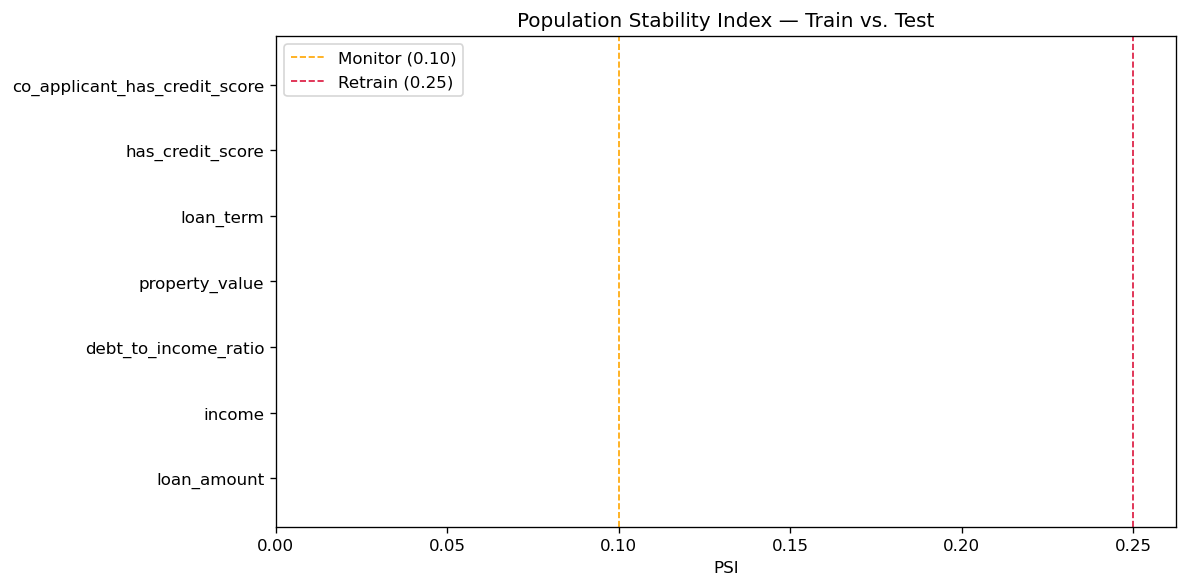

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = psi_df['status'].map({'STABLE': 'steelblue', 'MONITOR': 'orange', 'RETRAIN': 'crimson'})
ax.barh(psi_df['feature'], psi_df['PSI'], color=colors)
ax.axvline(0.10, color='orange', linestyle='--', linewidth=1, label='Monitor (0.10)')
ax.axvline(0.25, color='crimson', linestyle='--', linewidth=1, label='Retrain (0.25)')
ax.set_xlabel('PSI')
ax.set_title('Population Stability Index — Train vs. Test')
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'A1_psi.png'))
plt.show()

### A2. Kolmogorov–Smirnov (KS) Test
$$D = \sup_x |F_1(x) - F_2(x)|$$

In [13]:
ks_results = []
for col in numeric_features:
    train_vals = X_train[col].dropna()
    test_vals  = X_test[col].dropna()
    stat, pval = ks_2samp(train_vals, test_vals)
    ks_results.append({
        'feature': col,
        'KS_stat': round(stat, 4),
        'p_value': round(pval, 4),
        'sig':     '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else ''))
    })

ks_df = pd.DataFrame(ks_results).sort_values('KS_stat', ascending=False)
print('── KS Test Results (Lecture 04 eq. 4.2) ──')
print(ks_df.to_string(index=False))
print('\n* p<0.05  ** p<0.01  *** p<0.001')

── KS Test Results (Lecture 04 eq. 4.2) ──
                      feature  KS_stat  p_value sig
                  loan_amount   0.0010   0.1302    
                       income   0.0008   0.3168    
         debt_to_income_ratio   0.0004   0.9772    
               property_value   0.0004   0.9759    
                    loan_term   0.0004   0.9552    
             has_credit_score   0.0001   1.0000    
co_applicant_has_credit_score   0.0001   1.0000    

* p<0.05  ** p<0.01  *** p<0.001


### A3. Maximum Mean Discrepancy (MMD)
$$\text{MMD}^2(X,Y) = \frac{1}{m(m-1)}\sum_{i}\sum_{j\ne i} k(x_i,x_j) - \frac{2}{m^2}\sum_i\sum_j k(x_i,y_j) + \frac{1}{m(m-1)}\sum_i\sum_{j\ne i} k(y_i,y_j)$$

In [14]:
def compute_mmd_squared(X, Y, sigma=1.0):
    gamma = 1.0 / (2.0 * sigma ** 2)
    K_XX = rbf_kernel(X, X, gamma=gamma)
    K_YY = rbf_kernel(Y, Y, gamma=gamma)
    K_XY = rbf_kernel(X, Y, gamma=gamma)
    np.fill_diagonal(K_XX, 0)
    np.fill_diagonal(K_YY, 0)
    m = X.shape[0]
    A = K_XX.sum() / (m * (m - 1))
    B = K_XY.mean()
    C = K_YY.sum() / (m * (m - 1))
    return A - 2 * B + C


np.random.seed(42)
n_sample  = min(500, len(X_train_filled), len(X_test_filled))
idx_train = np.random.choice(len(X_train_filled), n_sample, replace=False)
idx_test  = np.random.choice(len(X_test_filled),  n_sample, replace=False)

X_tr_sample = X_train_filled.iloc[idx_train].values
X_te_sample = X_test_filled.iloc[idx_test].values

mmd2 = compute_mmd_squared(X_tr_sample, X_te_sample, sigma=1.0)
print(f'── MMD² (train vs test, n={n_sample} subsample) ──')
print(f'MMD² = {mmd2:.6f}')
print('Interpretation: values near 0 → distributions similar; larger → more divergence')

── MMD² (train vs test, n=500 subsample) ──
MMD² = -0.000008
Interpretation: values near 0 → distributions similar; larger → more divergence


### A4. Predicted Score Distribution: Train vs. Test

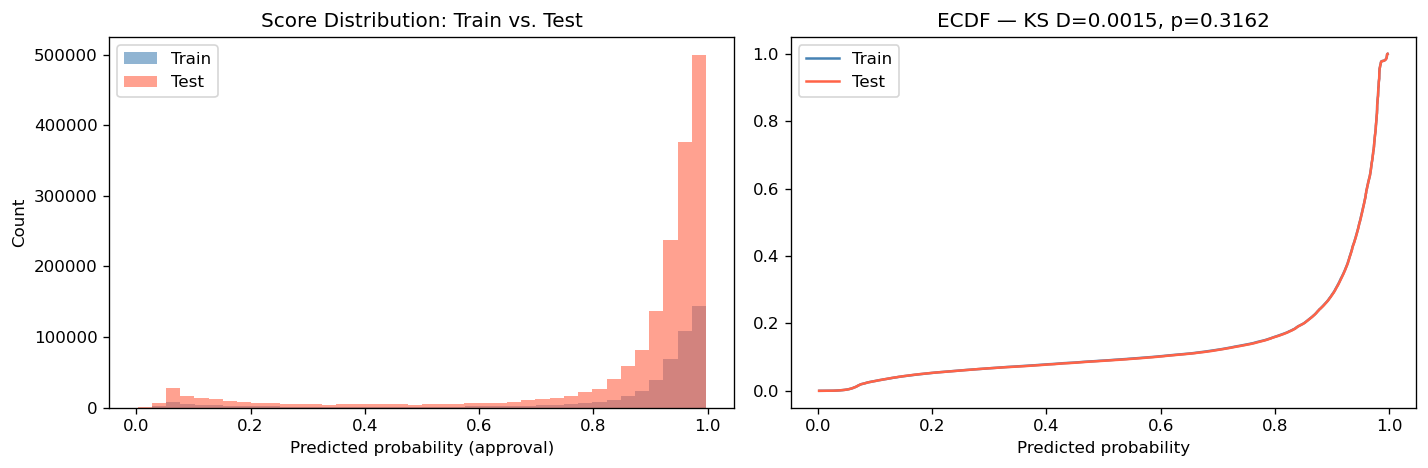

Score PSI: 0.0000 → STABLE
Score KS:  D=0.0015, p=0.3162


In [15]:
train_probs = model.predict_proba(X_train_filled)[:, 1]
test_probs  = model.predict_proba(X_test_filled)[:, 1]

score_ks_stat, score_ks_pval = ks_2samp(train_probs, test_probs)
score_psi = compute_psi(train_probs, test_probs, bins=10)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_probs, bins=40, alpha=0.6, color='steelblue', label='Train')
axes[0].hist(test_probs,  bins=40, alpha=0.6, color='tomato',    label='Test')
axes[0].set_xlabel('Predicted probability (approval)')
axes[0].set_ylabel('Count')
axes[0].set_title('Score Distribution: Train vs. Test')
axes[0].legend()

# ECDF
for probs, label, color in [(train_probs, 'Train', 'steelblue'), (test_probs, 'Test', 'tomato')]:
    sorted_p = np.sort(probs)
    cdf = np.arange(1, len(sorted_p) + 1) / len(sorted_p)
    axes[1].plot(sorted_p, cdf, label=label, color=color)
axes[1].set_xlabel('Predicted probability')
axes[1].set_title(f'ECDF — KS D={score_ks_stat:.4f}, p={score_ks_pval:.4f}')
axes[1].legend()

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'A4_score_distribution.png'))
plt.show()

print(f'Score PSI: {score_psi:.4f} → {psi_flag(score_psi)}')
print(f'Score KS:  D={score_ks_stat:.4f}, p={score_ks_pval:.4f}')

### A5. Drift Type Diagnosis

| Shift Type | P(X) | P(Y\|X) | Remedy |
|---|---|---|---|
| Covariate shift | Changes | Stable | Importance weighting |
| Label shift | Stable | Stable | Threshold recalibration |
| Concept drift | Any | Changes | Retraining / online learning |
| Sample selection bias | Biased | Stable | Collect representative data |

In [16]:
feature_drift    = (psi_df['status'] != 'STABLE').any()
label_rate_train = y_train.mean()
label_rate_test  = y_test.mean()
label_shift      = abs(label_rate_train - label_rate_test) > 0.02

print('── Drift Type Diagnosis (Lecture 04 slide 17–19) ──')
print(f'Feature distribution shift (PSI): {"YES" if feature_drift else "NO"}')
print(f'Label rate — Train: {label_rate_train:.3f} | Test: {label_rate_test:.3f}')
print(f'Label shift (>2pp delta):          {"YES" if label_shift else "NO"}')
print()

if feature_drift and not label_shift:
    print('DIAGNOSIS: Covariate shift — P(X) changed, P(Y|X) likely stable.')
    print('REMEDY: Importance weighting; monitor with rolling AUC.')
elif label_shift and not feature_drift:
    print('DIAGNOSIS: Label/prior shift — P(Y) changed, P(X|Y) likely stable.')
    print('REMEDY: Threshold recalibration.')
elif feature_drift and label_shift:
    print('DIAGNOSIS: Dataset shift — both P(X) and P(Y) have changed.')
    print('REMEDY: Investigate concept drift; consider retraining.')
else:
    print('DIAGNOSIS: No significant drift detected.')
    print('ACTION: Continue monitoring with PSI monthly.')

── Drift Type Diagnosis (Lecture 04 slide 17–19) ──
Feature distribution shift (PSI): NO
Label rate — Train: 0.757 | Test: 0.757
Label shift (>2pp delta):          NO

DIAGNOSIS: No significant drift detected.
ACTION: Continue monitoring with PSI monthly.


---
## Part B: Generalization Gap & Spurious Correlations

> $$G_{\text{gap}}(\hat{h}) = R_{\text{true}}(\hat{h}) - R_{\text{emp}}(\hat{h})$$
> A large gap means in-training performance **cannot be trusted in deployment** (Lecture 04, eq. 2.3).

### B1. Train vs. Test Performance Gap

In [17]:
train_prob = model.predict_proba(X_train_filled)[:, 1]
test_prob  = model.predict_proba(X_test_filled)[:, 1]
train_pred = model.predict(X_train_filled)
test_pred  = model.predict(X_test_filled)

perf_rows = []
for name, y_true, y_prob, y_pred in [
    ('Train (R_emp)',  y_train, train_prob, train_pred),
    ('Test  (R_true)', y_test,  test_prob,  test_pred)
]:
    perf_rows.append({
        'Split':    name,
        'AUC':      round(roc_auc_score(y_true, y_prob), 4),
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'F1':       round(f1_score(y_true, y_pred), 4),
        'Log Loss': round(log_loss(y_true, y_prob), 4),
        'Brier':    round(brier_score_loss(y_true, y_prob), 4),
    })

perf_df = pd.DataFrame(perf_rows).set_index('Split')
gap_row  = perf_df.loc['Test  (R_true)'] - perf_df.loc['Train (R_emp)']
gap_row.name = 'G_gap (Test - Train)'
perf_df = pd.concat([perf_df, gap_row.to_frame().T])

print('── Generalization Gap Table (Lecture 04 eq. 2.3) ──')
print(perf_df.to_string())
print()
print('Large negative G_gap on AUC → overfitting (Lecture 04 slide 9)')
print('Near-zero G_gap → good generalization')

── Generalization Gap Table (Lecture 04 eq. 2.3) ──
                         AUC  Accuracy      F1  Log Loss  Brier
Train (R_emp)         0.8534    0.8346  0.9008    0.4297  0.130
Test  (R_true)        0.8515    0.8333  0.9001    0.4329  0.131
G_gap (Test - Train) -0.0019   -0.0013 -0.0007    0.0032  0.001

Large negative G_gap on AUC → overfitting (Lecture 04 slide 9)
Near-zero G_gap → good generalization


### B2. Spurious Correlation Probe — Permutation Importance

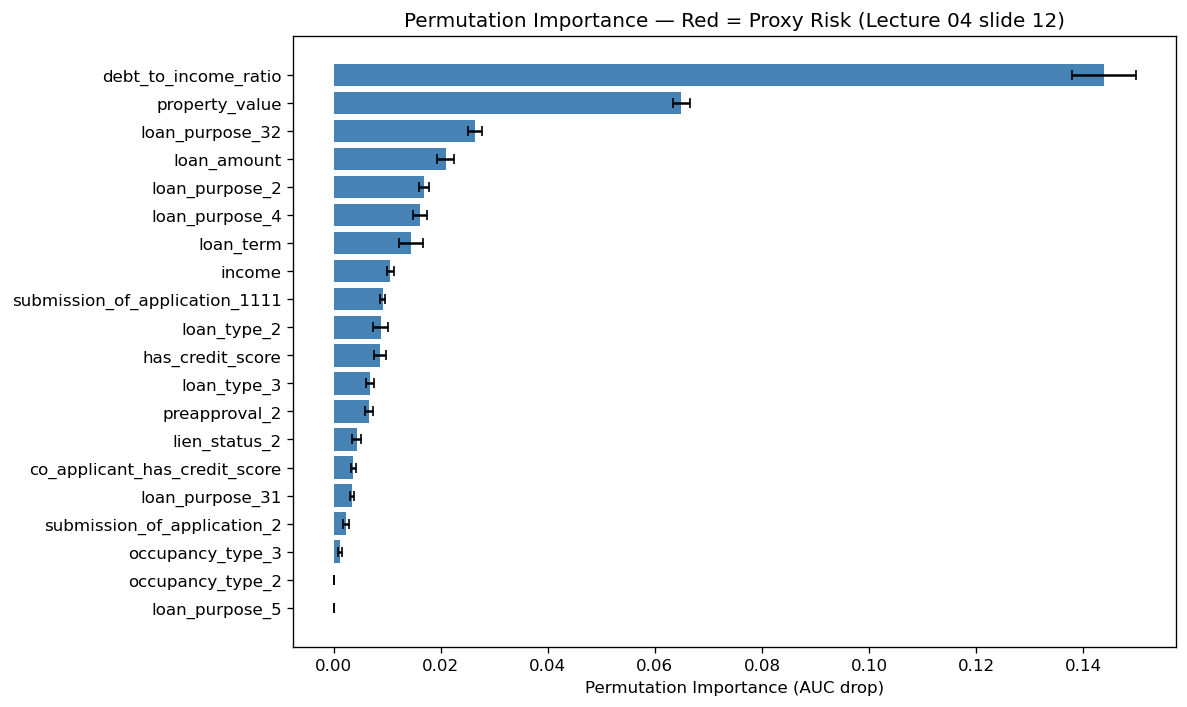

No geographic proxy features detected in top importance scores.


In [18]:
# Subsample X_test for permutation importance — avoids memory issues
np.random.seed(42)
perm_sample_idx = np.random.choice(len(X_test_filled), min(5000, len(X_test_filled)), replace=False)
X_perm_sample   = X_test_filled.iloc[perm_sample_idx]
y_perm_sample   = y_test.iloc[perm_sample_idx]

perm_result = permutation_importance(
    model, X_perm_sample, y_perm_sample,
    n_repeats=5, random_state=42, scoring='roc_auc', n_jobs=1
)

perm_df = pd.DataFrame({
    'feature':    X_test.columns,
    'importance': perm_result.importances_mean,
    'std':        perm_result.importances_std
}).sort_values('importance', ascending=False)

PROXY_FLAGS = ['census_tract', 'tract_', 'county_code', 'msa_md', 'state_code', 'zip', 'geo']
perm_df['proxy_risk'] = perm_df['feature'].apply(
    lambda f: 'FLAG' if any(p in f.lower() for p in PROXY_FLAGS) else ''
)

fig, ax = plt.subplots(figsize=(10, 6))
top20  = perm_df.head(20)
colors = ['crimson' if r == 'FLAG' else 'steelblue' for r in top20['proxy_risk']]
ax.barh(top20['feature'], top20['importance'], xerr=top20['std'], color=colors, capsize=3)
ax.set_xlabel('Permutation Importance (AUC drop)')
ax.set_title('Permutation Importance — Red = Proxy Risk (Lecture 04 slide 12)')
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'B2_permutation_importance.png'))
plt.show()

flagged = perm_df[perm_df['proxy_risk'] == 'FLAG']
if not flagged.empty:
    print('\n── Flagged Proxy Features ──')
    print(flagged[['feature', 'importance']].to_string(index=False))
    print('\nGovernance note: may encode race via geographic redlining (Lecture 04 slide 14)')
else:
    print('No geographic proxy features detected in top importance scores.')

### B3. Shortcut Learning Check — Counterfactual Swaps

In [19]:
PROTECTED_KEYWORDS = ['race', 'sex', 'ethnicity', 'gender']
cf_candidates = [
    c for c in X_test.columns
    if any(kw in c.lower() for kw in PROTECTED_KEYWORDS)
]

if cf_candidates:
    print(f'WARNING: Protected-attribute columns found in X: {cf_candidates}')
    baseline_probs = model.predict_proba(X_test_filled)[:, 1].mean()
    for col in cf_candidates:
        X_swapped = X_test_filled.copy()
        X_swapped[col] = 1 - X_swapped[col].clip(0, 1)
        swapped_probs = model.predict_proba(X_swapped)[:, 1].mean()
        delta = swapped_probs - baseline_probs
        print(f'  {col}: baseline={baseline_probs:.4f}, swapped={swapped_probs:.4f}, delta={delta:+.4f}')
    print('\nNon-zero delta = shortcut learning (Lecture 04 slide 13)')
else:
    print('No protected-attribute columns in X_test — correctly excluded.')
    print('Shortcut check via permutation importance (B2) is the appropriate diagnostic.')

No protected-attribute columns in X_test — correctly excluded.
Shortcut check via permutation importance (B2) is the appropriate diagnostic.


---
## Part C: Robustness & Stress Testing

> **Definition (Lecture 04 slide 26):** A model is **robust** if its performance degrades *gracefully* — not catastrophically — under perturbation, shift, or adversarial inputs.

### C1. Slice-Based Evaluation

$$\mathcal{S}_k = \{(x,y) \in \mathcal{D}_{\text{eval}} : \phi_k(x) = \top\}$$

> **Red flag (Lecture 04 slide 32):** A slice accounting for 5% of the population but 30% of the losses is a governance priority, not a statistical footnote.

In [22]:
def slice_metrics(y_true, y_pred_prob, y_pred, group_series, min_n=30):
    y_true_bool = y_true.astype(bool)
    results = []
    for group in group_series.unique():
        if pd.isna(group):
            continue
        mask = (group_series == group).values
        n = mask.sum()
        if n < min_n:
            continue
        yt  = y_true.values[mask]
        yp  = y_pred_prob[mask]
        ypb = y_pred[mask]
        ytb = y_true_bool.values[mask]
        if len(np.unique(yt)) < 2:
            continue
        fp  = (ypb.astype(bool) & ~ytb).sum()
        tn  = (~ypb.astype(bool) & ~ytb).sum()
        fn  = (~ypb.astype(bool) & ytb).sum()
        tp  = (ypb.astype(bool) & ytb).sum()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        results.append({
            'group':         group,
            'n':             n,
            'pct_of_data':   round(n / len(y_true) * 100, 1),
            'approval_rate': round(yt.mean(), 4),
            'AUC':           round(roc_auc_score(yt, yp), 4),
            'F1':            round(f1_score(yt, ypb), 4),
            'FPR':           round(fpr, 4),
            'FNR':           round(fnr, 4),
            'Brier':         round(brier_score_loss(yt, yp), 4),
        })
    return pd.DataFrame(results).set_index('group').sort_values('AUC')


y_pred_prob = model.predict_proba(X_test_filled)[:, 1]
y_pred      = model.predict(X_test_filled)

slice_cols    = ['derived_race', 'derived_sex', 'derived_ethnicity']
slice_results = {}

for col in slice_cols:
    if col not in prot_test.columns:
        continue
    print(f'\n── Slice: {col} ──')
    df = slice_metrics(y_test, y_pred_prob, y_pred, prot_test[col])
    slice_results[col] = df
    print(df.to_string())


── Slice: derived_race ──
                                                 n  pct_of_data  approval_rate     AUC      F1     FPR     FNR   Brier
group                                                                                                                 
Black or African American                   152205          8.8         0.6319  0.8426  0.8370  0.6418  0.0114  0.1874
White                                      1110566         64.1         0.7822  0.8480  0.9108  0.6645  0.0091  0.1198
Race Not Available                          305341         17.6         0.7225  0.8525  0.8824  0.6729  0.0065  0.1495
Joint                                        37823          2.2         0.8026  0.8547  0.9149  0.7309  0.0052  0.1185
Native Hawaiian or Other Pacific Islander     4239          0.2         0.6044  0.8634  0.8321  0.5814  0.0164  0.1825
American Indian or Alaska Native             12613          0.7         0.6316  0.8672  0.8429  0.6139  0.0105  0.1764
Free Form Text Only  

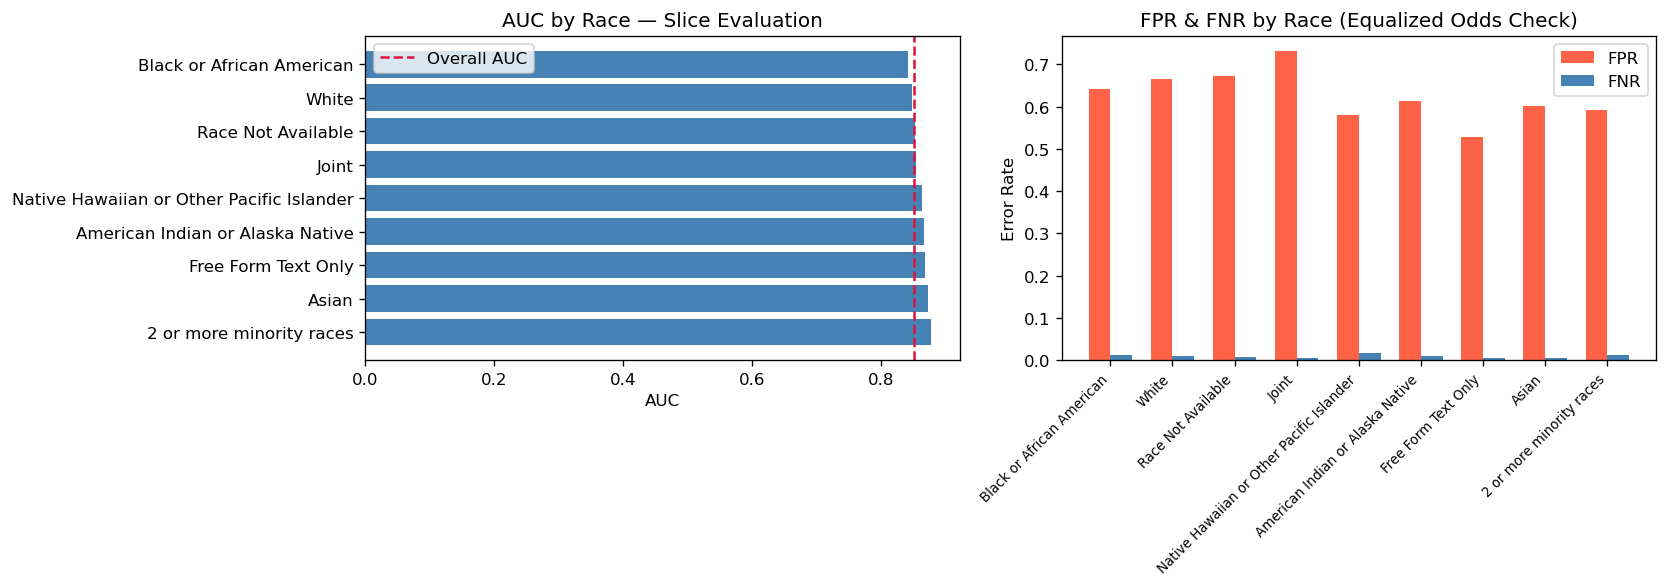

In [23]:
if 'derived_race' in slice_results:
    race_df = slice_results['derived_race'].reset_index()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].barh(race_df['group'], race_df['AUC'], color='steelblue')
    axes[0].axvline(roc_auc_score(y_test, y_pred_prob), color='crimson',
                   linestyle='--', label='Overall AUC')
    axes[0].set_xlabel('AUC')
    axes[0].set_title('AUC by Race — Slice Evaluation')
    axes[0].legend()
    axes[0].invert_yaxis()

    x = np.arange(len(race_df))
    width = 0.35
    axes[1].bar(x - width/2, race_df['FPR'], width, label='FPR', color='tomato')
    axes[1].bar(x + width/2, race_df['FNR'], width, label='FNR', color='steelblue')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(race_df['group'], rotation=45, ha='right', fontsize=8)
    axes[1].set_ylabel('Error Rate')
    axes[1].set_title('FPR & FNR by Race (Equalized Odds Check)')
    axes[1].legend()

    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, 'C1_slice_race.png'))
    plt.show()

### C2. Macroeconomic Scenario Stress Testing

HMDA analog of DFAST-style validation (Lecture 04 slide 34).

In [24]:
scenarios = {
    'Baseline':            X_test_filled.copy(),
    'Income shock -20%':   X_test_filled.copy(),
    'Property value -20%': X_test_filled.copy(),
    'DTI +10 points':      X_test_filled.copy(),
    'Loan amount +15%':    X_test_filled.copy(),
    'Combined adverse':    X_test_filled.copy(),
}

if 'income' in X_test_filled.columns:
    scenarios['Income shock -20%']['income'] = X_test_filled['income'] * 0.80
if 'property_value' in X_test_filled.columns:
    scenarios['Property value -20%']['property_value'] = X_test_filled['property_value'] * 0.80
if 'debt_to_income_ratio' in X_test_filled.columns:
    scenarios['DTI +10 points']['debt_to_income_ratio'] = X_test_filled['debt_to_income_ratio'] + 10
if 'loan_amount' in X_test_filled.columns:
    scenarios['Loan amount +15%']['loan_amount'] = X_test_filled['loan_amount'] * 1.15

# Combined adverse scenario
X_c = X_test_filled.copy()
if 'income' in X_c:               X_c['income']               = X_c['income'] * 0.80
if 'property_value' in X_c:       X_c['property_value']       = X_c['property_value'] * 0.80
if 'debt_to_income_ratio' in X_c: X_c['debt_to_income_ratio'] = X_c['debt_to_income_ratio'] + 10
scenarios['Combined adverse'] = X_c

baseline_prob = model.predict_proba(scenarios['Baseline'])[:, 1]

stress_rows = []
for scenario_name, X_s in scenarios.items():
    probs    = model.predict_proba(X_s)[:, 1]
    preds    = model.predict(X_s)
    approval = probs.mean()
    delta    = approval - baseline_prob.mean()
    stress_rows.append({
        'Scenario':      scenario_name,
        'Mean Approval': round(approval, 4),
        'Delta vs Base': round(delta, 4),
        'AUC':           round(roc_auc_score(y_test, probs), 4),
        'F1':            round(f1_score(y_test, preds), 4),
    })

stress_df = pd.DataFrame(stress_rows).set_index('Scenario')
print('── Stress Test Results (Lecture 04 slide 34 — DFAST analog) ──')
print(stress_df.to_string())
print('\nLarge Delta vs Base → model not robust to macroeconomic shock (Lecture 04 slide 26)')

── Stress Test Results (Lecture 04 slide 34 — DFAST analog) ──
                     Mean Approval  Delta vs Base     AUC      F1
Scenario                                                         
Baseline                    0.8603         0.0000  0.8515  0.9001
Income shock -20%           0.8576        -0.0027  0.8505  0.9004
Property value -20%         0.8526        -0.0077  0.8370  0.8991
DTI +10 points              0.7723        -0.0880  0.7918  0.8759
Loan amount +15%            0.8588        -0.0015  0.8493  0.9000
Combined adverse            0.7575        -0.1028  0.7752  0.8711

Large Delta vs Base → model not robust to macroeconomic shock (Lecture 04 slide 26)


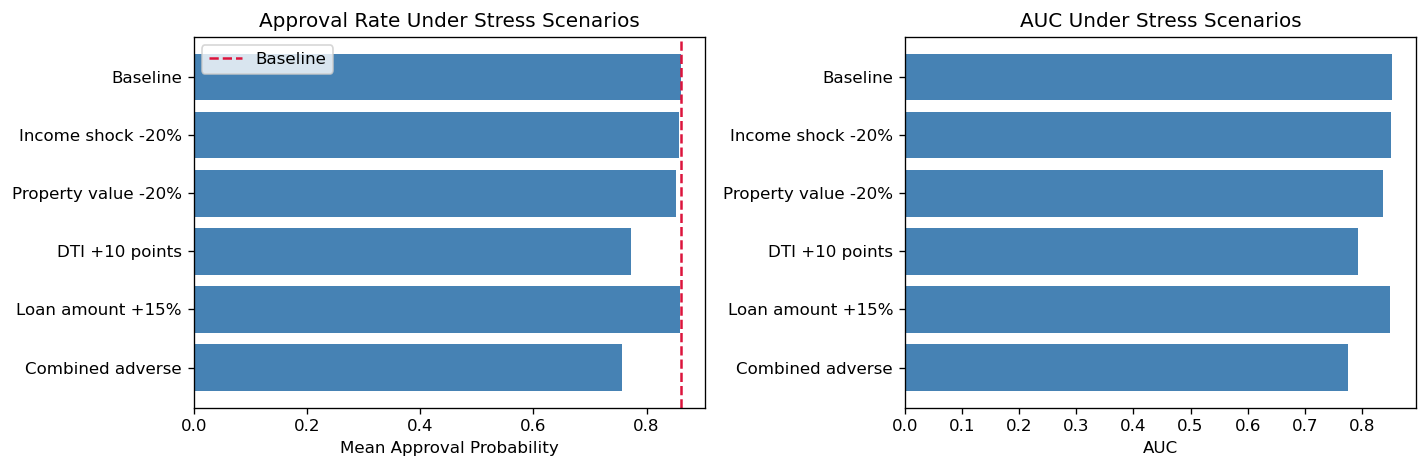

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stress_plot = stress_df.reset_index()

axes[0].barh(stress_plot['Scenario'], stress_plot['Mean Approval'], color='steelblue')
axes[0].axvline(stress_plot['Mean Approval'].iloc[0], color='crimson',
               linestyle='--', label='Baseline')
axes[0].set_xlabel('Mean Approval Probability')
axes[0].set_title('Approval Rate Under Stress Scenarios')
axes[0].legend()
axes[0].invert_yaxis()

axes[1].barh(stress_plot['Scenario'], stress_plot['AUC'], color='steelblue')
axes[1].set_xlabel('AUC')
axes[1].set_title('AUC Under Stress Scenarios')
axes[1].invert_yaxis()

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'C2_stress_scenarios.png'))
plt.show()

### C3. ICE Curves & Sensitivity Analysis

ICE reveals **heterogeneous effects** (Lecture 04 slide 33).
Sensitivity index: $V_j = \text{Var}_{x_j}[\mathbb{E}_{x_{-j}}[\hat{f}(X)]]$ — high $V_j$ with low domain justification → spurious reliance (eq. 6.2).

ICE features selected: ['debt_to_income_ratio', 'property_value', 'loan_amount']


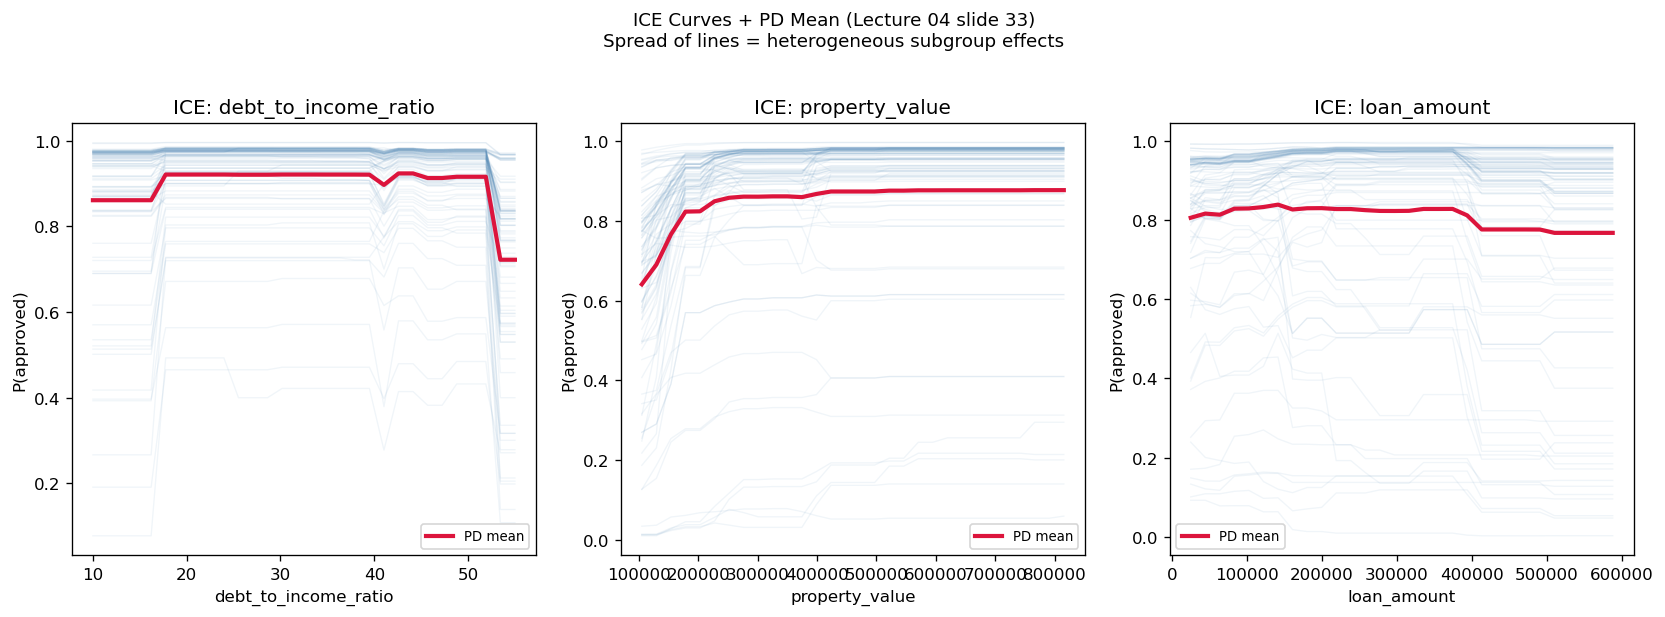

In [26]:
# ── Manual ICE plots — works with any model including Pipeline ────────────────
np.random.seed(42)
ice_sample_idx = np.random.choice(len(X_test_filled), min(100, len(X_test_filled)), replace=False)
X_ice_sample   = X_test_filled.iloc[ice_sample_idx].reset_index(drop=True)

# Only use continuous numeric features for ICE — skip booleans (get_dummies output)
# Boolean/binary features don't have meaningful gradients for ICE curves
candidate_features = [
    f for f in perm_df['feature'].head(10).tolist()
    if X_ice_sample[f].dtype in ['float64', 'float32', 'int64', 'int32']
    and X_ice_sample[f].nunique() > 5   # skip near-binary columns
]
top_features_for_ice = candidate_features[:3]

print(f'ICE features selected: {top_features_for_ice}')

if len(top_features_for_ice) == 0:
    print('No suitable continuous features found for ICE — skipping.')
else:
    fig, axes = plt.subplots(1, len(top_features_for_ice), figsize=(14, 5))
    if len(top_features_for_ice) == 1:
        axes = [axes]

    for ax, feat in zip(axes, top_features_for_ice):
        # Convert to float to avoid boolean quantile errors
        feat_series = X_ice_sample[feat].astype(float)
        feat_vals   = np.linspace(
            feat_series.quantile(0.05),
            feat_series.quantile(0.95),
            30
        )

        ice_lines = []
        for i in range(len(X_ice_sample)):
            # Repeat instance i across 30 grid rows
            X_grid = pd.DataFrame(
                [X_ice_sample.iloc[i].values] * 30,
                columns=X_ice_sample.columns
            )
            X_grid[feat] = feat_vals
            preds = model.predict_proba(X_grid)[:, 1]
            ice_lines.append(preds)

        ice_array = np.array(ice_lines)   # (n_instances, 30)
        pd_mean   = ice_array.mean(axis=0)

        for line in ice_array:
            ax.plot(feat_vals, line, alpha=0.08, color='steelblue', linewidth=0.8)
        ax.plot(feat_vals, pd_mean, color='crimson', linewidth=2.5, label='PD mean')
        ax.set_xlabel(feat)
        ax.set_ylabel('P(approved)')
        ax.set_title(f'ICE: {feat}')
        ax.legend(fontsize=8)

    fig.suptitle(
        'ICE Curves + PD Mean (Lecture 04 slide 33)\n'
        'Spread of lines = heterogeneous subgroup effects',
        fontsize=11, y=1.02
    )
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, 'C3_ice_curves.png'), bbox_inches='tight')
    plt.show()

In [27]:
from sklearn.inspection import partial_dependence

sensitivity_rows = []
for feat in perm_df['feature'].head(10):
    try:
        pd_result = partial_dependence(
            model, X_ice_sample, features=[feat],
            kind='individual', grid_resolution=20
        )
        ice_predictions = pd_result['individual'][0]
        v_j = ice_predictions.var(axis=1).mean()
        sensitivity_rows.append({
            'feature':           feat,
            'V_j (sensitivity)': round(float(v_j), 6),
            'proxy_risk':        perm_df.loc[perm_df['feature'] == feat, 'proxy_risk'].values[0]
        })
    except Exception:
        pass

sens_df = pd.DataFrame(sensitivity_rows).sort_values('V_j (sensitivity)', ascending=False)
print('── Sensitivity Index V_j (Lecture 04 eq. 6.2) ──')
print(sens_df.to_string(index=False))
print('\nHigh V_j + low domain justification → spurious reliance → flag for MRM file')

── Sensitivity Index V_j (Lecture 04 eq. 6.2) ──
                       feature  V_j (sensitivity) proxy_risk
          debt_to_income_ratio           0.027563           
                property_value           0.005839           
               loan_purpose_32           0.004451           
                   loan_type_2           0.004287           
                   loan_amount           0.004172           
                loan_purpose_2           0.002814           
                     loan_term           0.002373           
submission_of_application_1111           0.002119           
                loan_purpose_4           0.001994           
                        income           0.000781           

High V_j + low domain justification → spurious reliance → flag for MRM file


---
## Summary: Robustness Audit Report

In [29]:
summary = pd.DataFrame([
    {
        'Risk Type':          'Covariate shift',
        'Metric':             'PSI per feature',
        'What It Detects':    'Input distribution has changed',
        'Failure Mode':       'Model sees OOD inputs at inference',
        'HMDA Finding':       str(psi_df[psi_df['status'] != 'STABLE']['feature'].tolist() or 'None flagged'),
        'Policy Implication': 'Importance weighting; monthly PSI monitoring'
    },
    {
        'Risk Type':          'Generalization failure',
        'Metric':             'G_gap (AUC train − test)',
        'What It Detects':    'Overfitting; model memorized training quirks',
        'Failure Mode':       'High variance; audit-trail gaps',
        'HMDA Finding':       f"Gap = {perf_df.loc['G_gap (Test - Train)', 'AUC']:.4f}",
        'Policy Implication': 'Simplify model or add regularization'
    },
    {
        'Risk Type':          'Spurious correlation',
        'Metric':             'Permutation importance + proxy flag',
        'What It Detects':    'Model relies on unstable or proxy signals',
        'Failure Mode':       'Correct predictions for wrong reasons',
        'HMDA Finding':       str(flagged['feature'].tolist() if not flagged.empty else 'None flagged'),
        'Policy Implication': 'Feature audit; remove or justify geographic vars'
    },
    {
        'Risk Type':          'Macroeconomic stress',
        'Metric':             'Approval rate delta under scenarios',
        'What It Detects':    'Model fragility to economic shocks',
        'Failure Mode':       'Catastrophic performance degradation',
        'HMDA Finding':       f"Combined adverse delta = {stress_df.loc['Combined adverse', 'Delta vs Base']:.4f}",
        'Policy Implication': 'Define retraining triggers for macro events'
    },
    {
        'Risk Type':          'Subgroup disparity',
        'Metric':             'Slice AUC + FPR/FNR by race/sex',
        'What It Detects':    'Unequal error rates across protected groups',
        'Failure Mode':       'Disparate impact (Lecture 03 + 04 connection)',
        'HMDA Finding':       'See slice_results above',
        'Policy Implication': 'Threshold adjustment; connect to 80% rule'
    },
    {
        'Risk Type':          'Temporal drift',
        'Metric':             'Rolling AUC window (lagging indicator)',
        'What It Detects':    'Silent concept drift post-deployment',
        'Failure Mode':       'Model trained on 2024 LAR; lending norms shift',
        'HMDA Finding':       'Not observable yet — monitoring plan required',
        'Policy Implication': 'Monthly rolling AUC; annual retraining review'
    },
])

print('══ Governance Summary Table (Lecture 04 slide 42) ══')
for _, row in summary.iterrows():
    print(f"\n▸ {row['Risk Type']}")
    print(f"  Metric:   {row['Metric']}")
    print(f"  Detects:  {row['What It Detects']}")
    print(f"  Failure:  {row['Failure Mode']}")
    print(f"  Finding:  {row['HMDA Finding']}")
    print(f"  Policy:   {row['Policy Implication']}")

gov_path = os.path.join(TABLES_DIR, 'robustness_governance_summary.csv')
summary.to_csv(gov_path, index=False)
print(f'\nGovernance summary saved → {gov_path}')

══ Governance Summary Table (Lecture 04 slide 42) ══

▸ Covariate shift
  Metric:   PSI per feature
  Detects:  Input distribution has changed
  Failure:  Model sees OOD inputs at inference
  Finding:  None flagged
  Policy:   Importance weighting; monthly PSI monitoring

▸ Generalization failure
  Metric:   G_gap (AUC train − test)
  Detects:  Overfitting; model memorized training quirks
  Failure:  High variance; audit-trail gaps
  Finding:  Gap = -0.0019
  Policy:   Simplify model or add regularization

▸ Spurious correlation
  Metric:   Permutation importance + proxy flag
  Detects:  Model relies on unstable or proxy signals
  Failure:  Correct predictions for wrong reasons
  Finding:  None flagged
  Policy:   Feature audit; remove or justify geographic vars

▸ Macroeconomic stress
  Metric:   Approval rate delta under scenarios
  Detects:  Model fragility to economic shocks
  Failure:  Catastrophic performance degradation
  Finding:  Combined adverse delta = -0.1028
  Policy:   De

---
## Monitoring Stack Recommendation

Per Lecture 04 slide 24: a monitoring stack should include **both** leading and lagging indicators.

| Indicator | Type | Metric | Frequency | Threshold | Action |
|---|---|---|---|---|---|
| Feature PSI — income, DTI, loan_amount | Leading | PSI | Monthly | > 0.10 monitor; > 0.25 retrain | Investigate input pipeline |
| Score distribution PSI | Leading | PSI on model outputs | Monthly | > 0.10 | Check for label shift |
| Rolling AUC by race | Lagging | AUC per group | Quarterly | Drop > 0.03 | Fairness audit |
| Rolling AUC overall | Lagging | AUC overall | Monthly | Drop > 0.02 | Model review |
| 80% rule ratio by race | Lagging | AIR | Quarterly | < 0.80 | Mitigation required |

> **Core principle:** Robustness testing asks whether the model *remains reliable* as conditions change — a prerequisite for defensible deployment.